# Phase 0 — Metrica Sample Game 1 dataset exploration

**Scope:** dataset understanding and reproducibility only. This notebook does not calculate defensive states, structural references, ambiguity, tactical roles, HMMs, machine-learning models, or composite scores.

The notebook keeps Metrica's raw normalized coordinates. It shows the raw representation before any plotting convention is applied. For pitch plots only, the y-axis is displayed downward so that `(0, 0)` appears at the top-left, matching Metrica's documentation; coordinate values are not changed.

Data source: [Metrica Sports sample-data](https://github.com/metrica-sports/sample-data), Sample Game 1 only. The three source CSVs are stored under the gitignored `data/metrica_sample_game_1/` directory.

## Reproducibility

From the repository root, create an environment and install `requirements-phase0.txt`, then run this notebook. The next cell downloads exactly one match only when a required file is missing and verifies fixed SHA-256 checksums.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import csv
import hashlib
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'README.md').exists() and (REPO_ROOT.parent / 'README.md').exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / 'data' / 'metrica_sample_game_1'
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = 'https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1'
FILES = {
    'home': ('Sample_Game_1_RawTrackingData_Home_Team.csv', '0a3d0eff7785950379c587d3597b86a2d91c2492281b4652e1abb97c99b6b364'),
    'away': ('Sample_Game_1_RawTrackingData_Away_Team.csv', '0a3df68a92af0290ede472e62de3b6489ddee29223da09bdf0cf76c8e0ab0618'),
    'events': ('Sample_Game_1_RawEventsData.csv', '097dda6345e17390dca095331458fd00e47960c480c76f4356fd4edf2575ef05'),
}

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

for key, (filename, expected_hash) in FILES.items():
    path = DATA_DIR / filename
    if not path.exists():
        print(f'Downloading {filename}')
        urlretrieve(f'{BASE_URL}/{filename}', path)
    actual_hash = sha256(path)
    if actual_hash != expected_hash:
        raise ValueError(f'Checksum mismatch for {filename}: {actual_hash}')

paths = {key: DATA_DIR / value[0] for key, value in FILES.items()}
print('Verified files:')
for key, path in paths.items():
    print(f'  {key:6s} {path.relative_to(REPO_ROOT)} ({path.stat().st_size:,} bytes)')

Verified files:
  home   data/metrica_sample_game_1/Sample_Game_1_RawTrackingData_Home_Team.csv (32,782,961 bytes)
  away   data/metrica_sample_game_1/Sample_Game_1_RawTrackingData_Away_Team.csv (32,782,073 bytes)
  events data/metrica_sample_game_1/Sample_Game_1_RawEventsData.csv (139,446 bytes)


## 1. Raw files and header representation

Tracking CSVs use three header rows. We display them before assigning convenient column names. The first two rows encode team and anonymized shirt/player identifiers; the third alternates unnamed x/y coordinate fields after each player label.

In [2]:
def raw_rows(path, n=5):
    with path.open(newline='') as stream:
        return [row for _, row in zip(range(n), csv.reader(stream))]

for key in ('home', 'away'):
    print(f'\n{key.upper()} first five raw rows:')
    for row in raw_rows(paths[key]):
        print(row)

print('\nEVENTS first three raw rows:')
for row in raw_rows(paths['events'], n=3):
    print(row)


HOME first five raw rows:
['', '', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', 'Home', '', '', '']
['', '', '', '11', '', '1', '', '2', '', '3', '', '4', '', '5', '', '6', '', '7', '', '8', '', '9', '', '10', '', '12', '', '13', '', '14', '', '', '']
['Period', 'Frame', 'Time [s]', 'Player11', '', 'Player1', '', 'Player2', '', 'Player3', '', 'Player4', '', 'Player5', '', 'Player6', '', 'Player7', '', 'Player8', '', 'Player9', '', 'Player10', '', 'Player12', '', 'Player13', '', 'Player14', '', 'Ball', '']
['1', '1', '0.04', '0.00082', '0.48238', '0.32648', '0.65322', '0.33701', '0.48863', '0.30927', '0.35529', '0.32137', '0.21262', '0.41094', '0.72589', '0.41698', '0.47843', '0.39125', '0.3255', '0.45388', '0.21174', '0.52697', '0.3798', '0.55243', '0.43269', 'NaN', 'NaN', 'NaN', 'NaN', 'NaN', 'NaN', '0.45472', '0.38709']
['1', '2', '0.08', '0.00096', '0.48238', '0.32648'

## 2. Minimal parsing

The only transformation here is naming alternating tracking columns as `Player<ID>_x`, `Player<ID>_y`, `Ball_x`, and `Ball_y`. Values, frames, times, periods, and coordinates are unchanged.

In [3]:
def load_tracking(path):
    header = pd.read_csv(path, header=None, nrows=3)
    player_ids = [str(int(float(value))) for value in header.iloc[1, 3:-2:2] if pd.notna(value)]
    columns = ['Period', 'Frame', 'Time [s]']
    for player_id in player_ids:
        columns.extend([f'Player{player_id}_x', f'Player{player_id}_y'])
    columns.extend(['Ball_x', 'Ball_y'])
    tracking = pd.read_csv(path, skiprows=3, names=columns)
    return tracking, player_ids, header

home, home_players, home_header = load_tracking(paths['home'])
away, away_players, away_header = load_tracking(paths['away'])
events = pd.read_csv(paths['events'])

print('Shapes')
print({'home_tracking': home.shape, 'away_tracking': away.shape, 'events': events.shape})
print('\nHome columns:', home.columns.tolist())
print('\nAway columns:', away.columns.tolist())
print('\nEvent columns:', events.columns.tolist())
print('\nIdentifiers represented in headers')
print('Home:', home_players)
print('Away:', away_players)
print('Ball: duplicated as Ball_x/Ball_y in both team tracking files')

Shapes
{'home_tracking': (145006, 33), 'away_tracking': (145006, 33), 'events': (1745, 14)}

Home columns: ['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player1_x', 'Player1_y', 'Player2_x', 'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y', 'Player5_x', 'Player5_y', 'Player6_x', 'Player6_y', 'Player7_x', 'Player7_y', 'Player8_x', 'Player8_y', 'Player9_x', 'Player9_y', 'Player10_x', 'Player10_y', 'Player12_x', 'Player12_y', 'Player13_x', 'Player13_y', 'Player14_x', 'Player14_y', 'Ball_x', 'Ball_y']

Away columns: ['Period', 'Frame', 'Time [s]', 'Player25_x', 'Player25_y', 'Player15_x', 'Player15_y', 'Player16_x', 'Player16_y', 'Player17_x', 'Player17_y', 'Player18_x', 'Player18_y', 'Player19_x', 'Player19_y', 'Player20_x', 'Player20_y', 'Player21_x', 'Player21_y', 'Player22_x', 'Player22_y', 'Player23_x', 'Player23_y', 'Player24_x', 'Player24_y', 'Player26_x', 'Player26_y', 'Player27_x', 'Player27_y', 'Player28_x', 'Player28_y', 'Ball_x', 'Ball_y']

Event c

## 3. Sampling, time, missingness, and coordinate ranges

Missing coordinate slots must not be interpreted automatically as tracking failures: each file has 14 anonymized player slots, while only the players active at a given time should have coordinates. Substitutions and non-participating slots can therefore create long missing runs. We report missingness without imputing it.

In [4]:
period_summary = home.groupby('Period').agg(
    rows=('Frame', 'size'),
    frame_min=('Frame', 'min'),
    frame_max=('Frame', 'max'),
    time_min_s=('Time [s]', 'min'),
    time_max_s=('Time [s]', 'max'),
)
print('Period/frame/time summary (raw global counters):')
display(period_summary)

dt = home.groupby('Period')['Time [s]'].diff().dropna()
print('Median time step:', dt.median(), 'seconds')
print('Implied sampling rate:', 1 / dt.median(), 'Hz')
print('Unique rounded time steps:', sorted(dt.round(6).unique())[:10])

def coordinate_columns(df):
    return [column for column in df if column.endswith(('_x', '_y'))]

def player_missingness(df, player_ids):
    rows = []
    for player_id in player_ids:
        pair = df[[f'Player{player_id}_x', f'Player{player_id}_y']]
        rows.append({
            'player': f'Player{player_id}',
            'both_coordinates_missing_pct': 100 * pair.isna().all(axis=1).mean(),
            'only_one_coordinate_missing_rows': int(pair.isna().any(axis=1).sum() - pair.isna().all(axis=1).sum()),
        })
    return pd.DataFrame(rows)

print('\nHome player-slot missingness:')
display(player_missingness(home, home_players))
print('Away player-slot missingness:')
display(player_missingness(away, away_players))
print('Ball missingness (% rows):', {
    'home_file': 100 * home[['Ball_x', 'Ball_y']].isna().any(axis=1).mean(),
    'away_file': 100 * away[['Ball_x', 'Ball_y']].isna().any(axis=1).mean(),
})

ranges = []
for name, frame in [('home_tracking', home), ('away_tracking', away)]:
    for axis in ('x', 'y'):
        columns = [column for column in coordinate_columns(frame) if column.endswith(f'_{axis}')]
        values = frame[columns].stack()
        ranges.append({'source': name, 'axis': axis, 'min': values.min(), 'max': values.max()})
for axis, columns in [('x', ['Start X', 'End X']), ('y', ['Start Y', 'End Y'])]:
    values = events[columns].stack()
    ranges.append({'source': 'events', 'axis': axis, 'min': values.min(), 'max': values.max()})
print('\nRaw coordinate ranges (no clipping or normalization):')
display(pd.DataFrame(ranges))

Period/frame/time summary (raw global counters):


,rows,frame_min,frame_max,time_min_s,time_max_s
Period,,,,,
1,71268,1,71268,0.04,2850.72
2,73738,71269,145006,2850.76,5800.24


Median time step: 0.03999999999996362 seconds
Implied sampling rate: 25.000000000022737 Hz
Unique rounded time steps: [np.float64(0.04)]

Home player-slot missingness:


,player,both_coordinates_missing_pct,only_one_coordinate_missing_rows
0,Player11,0.000000,0
1,Player1,67.790298,0
2,Player2,0.000000,0
3,Player3,0.000000,0
4,Player4,0.000000,0
5,Player5,0.000000,0
6,Player6,23.555577,0
7,Player7,0.000000,0
8,Player8,0.000000,0
9,Player9,0.000000,0


Away player-slot missingness:


,player,both_coordinates_missing_pct,only_one_coordinate_missing_rows
0,Player25,0.000000,0
1,Player15,0.000000,0
2,Player16,0.000000,0
3,Player17,0.000000,0
4,Player18,0.000000,0
5,Player19,17.671683,0
6,Player20,0.000000,0
7,Player21,0.000000,0
8,Player22,26.300291,0
9,Player23,0.000000,0


Ball missingness (% rows): {'home_file': np.float64(39.13975973407997), 'away_file': np.float64(39.13975973407997)}

Raw coordinate ranges (no clipping or normalization):


,source,axis,min,max
0,home_tracking,x,-0.04548,1.05996
1,home_tracking,y,-0.05000,1.05000
2,away_tracking,x,-0.04548,1.05996
3,away_tracking,y,-0.05000,1.05000
4,events,x,-0.05000,1.06000
5,events,y,-0.04000,1.04000


## 4. Tracking–event synchronization

Metrica documents the files as synchronized. We test that claim directly: Home/Away tracking keys, duplicated ball values, and event start/end frame-time pairs. End frame `0` is used by some instantaneous or opening events and is excluded from the end-frame match test rather than silently treated as a tracking frame.

In [5]:
key_columns = ['Period', 'Frame', 'Time [s]']
print('Home and Away keys exactly equal:', home[key_columns].equals(away[key_columns]))
ball_equal_or_both_missing = (
    home[['Ball_x', 'Ball_y']].eq(away[['Ball_x', 'Ball_y']])
    | (home[['Ball_x', 'Ball_y']].isna() & away[['Ball_x', 'Ball_y']].isna())
).all(axis=1)
print('Duplicated ball coordinates agree on every row:', bool(ball_equal_or_both_missing.all()))

tracking_keys = home[['Period', 'Frame', 'Time [s]']]
start_check = events.merge(
    tracking_keys, left_on=['Period', 'Start Frame'], right_on=['Period', 'Frame'], how='left'
)
start_check['absolute_time_difference_s'] = (start_check['Start Time [s]'] - start_check['Time [s]']).abs()
valid_ends = events.loc[events['End Frame'] > 0].copy()
end_check = valid_ends.merge(
    tracking_keys, left_on=['Period', 'End Frame'], right_on=['Period', 'Frame'], how='left'
)
end_check['absolute_time_difference_s'] = (end_check['End Time [s]'] - end_check['Time [s]']).abs()
sync_report = pd.Series({
    'event_start_rows': len(start_check),
    'start_frames_missing_from_tracking': int(start_check['Frame'].isna().sum()),
    'maximum_start_time_difference_s': start_check['absolute_time_difference_s'].max(),
    'event_end_rows_with_positive_frame': len(end_check),
    'end_frames_missing_from_tracking': int(end_check['Frame'].isna().sum()),
    'maximum_end_time_difference_s': end_check['absolute_time_difference_s'].max(),
})
display(sync_report.to_frame('value'))

Home and Away keys exactly equal: True
Duplicated ball coordinates agree on every row: True


,value
event_start_rows,1745.0
start_frames_missing_from_tracking,0.0
maximum_start_time_difference_s,0.0
event_end_rows_with_positive_frame,1744.0
end_frames_missing_from_tracking,0.0
maximum_end_time_difference_s,0.0


## 5. Attacking direction and halftime orientation

The files do not provide an explicit attacking-direction field. We infer direction cautiously from shot destination x-coordinates, then cross-check with the player in each team whose median x-position is closest to either end line. This second player is a geometric boundary-position candidate, not a tactically labeled goalkeeper. No coordinates are flipped.

In [6]:
shots = events.loc[events['Type'].eq('SHOT')].copy()
shot_direction = shots.groupby(['Team', 'Period']).agg(
    shots=('Type', 'size'),
    median_start_x=('Start X', 'median'),
    median_end_x=('End X', 'median'),
)
shot_direction['inferred_attack_direction'] = np.where(
    shot_direction['median_end_x'] > 0.5, 'toward increasing x', 'toward decreasing x'
)
print('Shot-location evidence:')
display(shot_direction)

def boundary_position_candidate(df, player_ids):
    distances = {}
    for player_id in player_ids:
        x = df[f'Player{player_id}_x'].dropna()
        distances[player_id] = np.minimum(x, 1 - x).median()
    return min(distances, key=distances.get), distances

boundary_rows = []
for team, frame, player_ids in [('Home', home, home_players), ('Away', away, away_players)]:
    candidate, _ = boundary_position_candidate(frame, player_ids)
    for period, subset in frame.groupby('Period'):
        boundary_rows.append({
            'team': team, 'candidate': f'Player{candidate}', 'period': period,
            'median_x': subset[f'Player{candidate}_x'].median(),
        })
boundary_evidence = pd.DataFrame(boundary_rows)
print('Boundary-position cross-check:')
display(boundary_evidence)

print('Conclusion: both shot destinations and boundary-position candidates reverse x ends between periods.')
print('The raw coordinate orientation stays fixed; the teams change attacking direction at halftime.')

Shot-location evidence:


shots  median_start_x  median_end_x inferred_attack_direction
Team Period                                                               
Away 1           2           0.165        -0.010       toward decreasing x
     2           4           0.805         1.005       toward increasing x
Home 1          11           0.920         1.020       toward increasing x
     2           7           0.080        -0.010       toward decreasing x

Boundary-position cross-check:


,team,candidate,period,median_x
0,Home,Player11,1,0.119520
1,Home,Player11,2,0.915945
2,Away,Player25,1,0.898210
3,Away,Player25,2,0.117835


Conclusion: both shot destinations and boundary-position candidates reverse x ends between periods.
The raw coordinate orientation stays fixed; the teams change attacking direction at halftime.


## 6. One complete raw tracking frame

A complete frame is defined operationally as 11 non-missing player coordinate pairs for each team plus a non-missing ball. This does not assert tactical formation or role. Labels are anonymized Metrica identifiers.

{'row_index': 0, 'frame': 1, 'time_s': np.float64(0.04), 'period': 1}


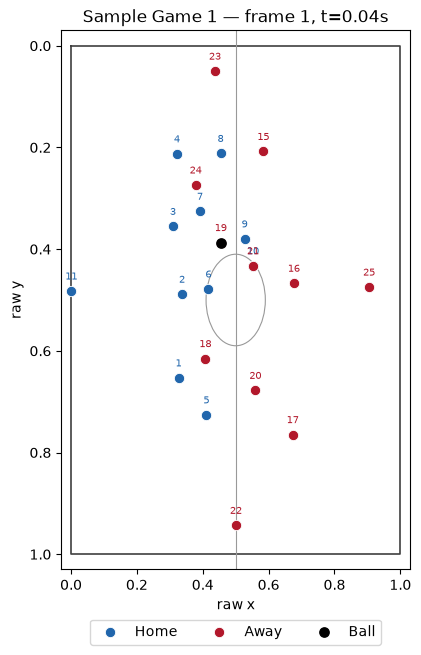

In [7]:
def present_player_count(df, player_ids):
    return sum(df[[f'Player{pid}_x', f'Player{pid}_y']].notna().all(axis=1) for pid in player_ids)

home_counts = present_player_count(home, home_players)
away_counts = present_player_count(away, away_players)
complete_mask = (home_counts == 11) & (away_counts == 11) & home[['Ball_x', 'Ball_y']].notna().all(axis=1)
complete_index = complete_mask[complete_mask].index[0]
frame_number = int(home.loc[complete_index, 'Frame'])
print({'row_index': int(complete_index), 'frame': frame_number, 'time_s': home.loc[complete_index, 'Time [s]'], 'period': int(home.loc[complete_index, 'Period'])})

def draw_raw_pitch(ax, title):
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='0.25', linewidth=1.2)
    ax.axvline(0.5, color='0.6', linewidth=0.8)
    circle = plt.Circle((0.5, 0.5), 0.09, fill=False, color='0.6', linewidth=0.8)
    ax.add_patch(circle)
    ax.set(xlim=(-0.03, 1.03), ylim=(1.03, -0.03), xlabel='raw x', ylabel='raw y', title=title)
    ax.set_aspect(105 / 68)

def plot_team_frame(ax, row, player_ids, color, label):
    first = True
    for pid in player_ids:
        x, y = row[f'Player{pid}_x'], row[f'Player{pid}_y']
        if pd.notna(x) and pd.notna(y):
            ax.scatter(x, y, s=55, color=color, edgecolor='white', linewidth=0.6, label=label if first else None, zorder=3)
            ax.text(x, y - 0.018, pid, color=color, fontsize=7, ha='center', va='bottom')
            first = False

fig, ax = plt.subplots(figsize=(11, 7))
draw_raw_pitch(ax, f'Sample Game 1 — frame {frame_number}, t={home.loc[complete_index, "Time [s]"]:.2f}s')
plot_team_frame(ax, home.loc[complete_index], home_players, '#2166ac', 'Home')
plot_team_frame(ax, away.loc[complete_index], away_players, '#b2182b', 'Away')
ax.scatter(home.loc[complete_index, 'Ball_x'], home.loc[complete_index, 'Ball_y'], s=45, color='black', marker='o', label='Ball', zorder=4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.show()

## 7. Raw trajectories over a seven-second sequence

The fixed window 44.4–51.4 seconds in Period 1 spans documented interception/recovery and pass events. It is selected for visibility, not tactical inference. Paths use every fifth tracking sample for legibility; original coordinates remain unchanged. The event rows overlapping the window are shown first.

,Team,Type,Subtype,Start Frame,Start Time [s],End Frame,End Time [s],From,To
23,Away,BALL LOST,INTERCEPTION,1110,44.40,1134,45.36,Player17,NaN
24,Home,RECOVERY,INTERCEPTION,1134,45.36,1134,45.36,Player5,NaN
25,Home,PASS,HEAD,1134,45.36,1154,46.16,Player5,Player6
26,Home,PASS,NaN,1154,46.16,1177,47.08,Player6,Player10
27,Home,PASS,NaN,1226,49.04,1266,50.64,Player10,Player8


Raw rows in full window: 176; plotted samples: 36


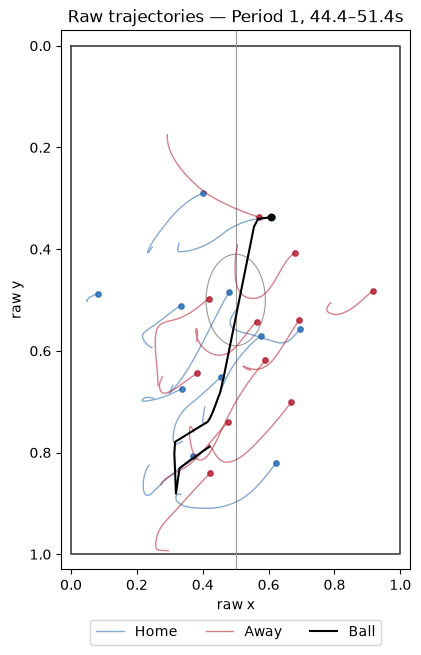

In [8]:
sequence_period = 1
sequence_start_s = 44.4
sequence_end_s = 51.4
event_overlap = events.loc[
    (events['Period'] == sequence_period)
    & (events['Start Time [s]'] <= sequence_end_s)
    & (events['End Time [s]'].where(events['End Time [s]'] > 0, events['Start Time [s]']) >= sequence_start_s),
    ['Team', 'Type', 'Subtype', 'Start Frame', 'Start Time [s]', 'End Frame', 'End Time [s]', 'From', 'To'],
]
display(event_overlap)

home_seq = home.loc[(home['Period'] == sequence_period) & home['Time [s]'].between(sequence_start_s, sequence_end_s)].iloc[::5]
away_seq = away.loc[(away['Period'] == sequence_period) & away['Time [s]'].between(sequence_start_s, sequence_end_s)].iloc[::5]
print(f'Raw rows in full window: {int((sequence_end_s - sequence_start_s) / 0.04) + 1}; plotted samples: {len(home_seq)}')

fig, ax = plt.subplots(figsize=(11, 7))
draw_raw_pitch(ax, f'Raw trajectories — Period {sequence_period}, {sequence_start_s:.1f}–{sequence_end_s:.1f}s')
for frame, player_ids, color, team in [
    (home_seq, home_players, '#2166ac', 'Home'),
    (away_seq, away_players, '#b2182b', 'Away'),
]:
    team_labeled = False
    for pid in player_ids:
        valid = frame[[f'Player{pid}_x', f'Player{pid}_y']].dropna()
        if not valid.empty:
            ax.plot(valid[f'Player{pid}_x'], valid[f'Player{pid}_y'], color=color, alpha=0.55, linewidth=1.0, label=team if not team_labeled else None)
            ax.scatter(valid[f'Player{pid}_x'].iloc[-1], valid[f'Player{pid}_y'].iloc[-1], color=color, s=15, alpha=0.8)
            team_labeled = True
ball_valid = home_seq[['Ball_x', 'Ball_y']].dropna()
ax.plot(ball_valid['Ball_x'], ball_valid['Ball_y'], color='black', linewidth=1.5, label='Ball')
ax.scatter(ball_valid['Ball_x'].iloc[-1], ball_valid['Ball_y'].iloc[-1], color='black', s=22)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.show()

## 8. Phase 0 observations, uncertainties, and problems

### Observed in Sample Game 1

- Home and Away tracking each contain 145,006 rows. Events contain 1,745 rows.
- Tracking is sampled at 25 Hz (`0.04 s` between frames). Frame and time counters continue globally across halftime rather than restarting.
- Each tracking file has 14 anonymized player slots, alternating x/y fields, plus duplicated ball x/y fields. Active-player availability varies through time.
- Home and Away frame/time keys match exactly. Event start and positive end frame/time pairs match tracking exactly in this file.
- Tracking and event coordinates use Metrica's raw nominally normalized system, but observed values extend slightly outside `[0, 1]`; these values are reported and not clipped.
- Shot destinations and boundary-position candidates both show that the teams switch attacking direction at halftime while the coordinate system stays fixed.

### Uncertainties and potential problems retained

- Player and team identities are anonymized; shirt-like identifiers do not supply tactical roles.
- Missing player slots can reflect substitutions or non-participation, but missing ball/player coordinates may also include genuine tracking gaps. Those causes are not separated here. Ball coordinates are absent on roughly 39% of rows in this match, which requires attention before choosing any later analysis window.
- Ball coordinates are duplicated in the two tracking files. They agree in this match, but code should continue to verify rather than assume agreement.
- The event table is sparse relative to tracking and does not describe every movement or possession state. Event absence is not evidence of tactical inactivity.
- Attacking direction is inferred from observed geometry because no explicit direction field was found.
- Displaying y downward is a plotting convention only. No metric conversion, centering, half flipping, smoothing, interpolation, velocity calculation, role inference, or tactical classification is performed.

**Stop condition:** Phase 0 ends here. Structural-reference calculations and all defensive-state constructs belong to a later, separately approved phase.